In [55]:
import numpy as np
import pandas as pd

In [56]:
df=pd.read_csv(r"C:\Users\vagee\OneDrive\Attachments\Desktop\ml\ml_learning\end-to-end-ml-implementing\dtaset.csv")

In [57]:
df.head()

,Serial,CGPA,IQ,Placement
0,1,8.2,112,1
1,2,7.1,95,0
2,3,9.1,118,1
3,4,6.8,88,0
4,5,8.5,105,1


In [58]:
df.shape

(35, 4)

preprocessing 


In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35 entries, 0 to 34
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Serial     35 non-null     int64  
 1   CGPA       35 non-null     float64
 2   IQ         35 non-null     int64  
 3   Placement  35 non-null     int64  
dtypes: float64(1), int64(3)
memory usage: 1.2 KB


In [60]:
df=df.iloc[:,1:] # removing the first column which is just an index and not useful for our model

In [61]:
df.head()

,CGPA,IQ,Placement
0,8.2,112,1
1,7.1,95,0
2,9.1,118,1
3,6.8,88,0
4,8.5,105,1


EDA

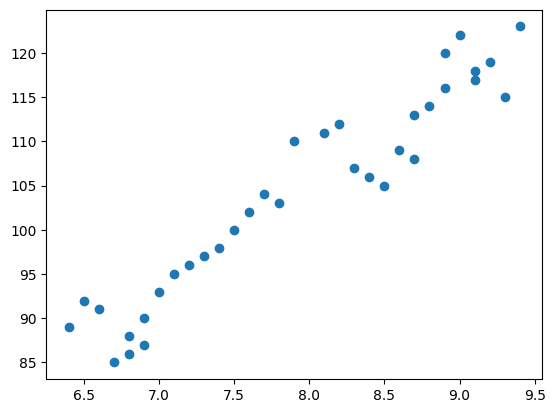

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.scatter(df['CGPA'],df['IQ'])
#this  scatter plot shows that there is a positive correlation between CGPA and IQ, meaning that as CGPA increases, IQ also tends to increase. This suggests that students with higher CGPA may also have higher IQ scores. However, it's important to note that correlation does not imply causation, and other factors may also be influencing this relationship.
#now  we  se  who get  the  job  offer


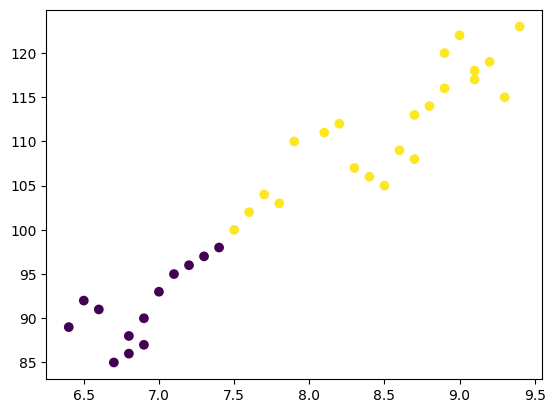

In [63]:
plt.scatter(df['CGPA'],df['IQ'],c=df['Placement'])
#this scatter plot shows the relationship between CGPA, IQ, and job placement. The color of the points indicates whether a student received a job offer (PLACEMENT). From the plot, we can observe that students with higher CGPA and IQ are more likely to receive job offers, as indicated by the clustering of colored points in the upper right corner of the plot. However, there are also some students with lower CGPA and IQ who received job offers, suggesting that other factors may also play a role in job placement.      

now  we  have  to  creat e an  model  that  understand  the  classify data

In [74]:
#using logistic  regration  cut  the  line  in dat   and  divide  in 2  parts  placed  and  not  placed  
#no need  of  featur  selection  as  we  have  only 2 features and 1 target variable

no  extrect input  and  output cols 


In [ ]:
x=df.iloc[:,0:2] # independent  variable
y=df.iloc[:,-1] # dependent variable

In [ ]:
x

,CGPA,IQ
0,8.2,112
1,7.1,95
2,9.1,118
3,6.8,88
4,8.5,105
5,7.9,110
6,6.5,92
7,8.9,120
8,7.4,98
9,9.3,115


In [ ]:
y


0     1
1     0
2     1
3     0
4     1
5     1
6     0
7     1
8     0
9     1
10    1
11    0
12    1
13    0
14    1
15    1
16    0
17    1
18    1
19    0
20    1
21    1
22    0
23    1
24    0
25    1
26    1
27    0
28    1
29    1
30    0
31    1
32    1
33    0
34    1
Name: Placement, dtype: int64

train test split  

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
x_train

,CGPA,IQ
12,8.7,108
8,7.4,98
16,6.7,85
9,9.3,115
33,6.8,86
0,8.2,112
4,8.5,105
17,8.8,114
27,6.9,87
5,7.9,110


In [ ]:
y_train

12    1
8     0
16    0
9     1
33    0
0     1
4     1
17    1
27    0
5     1
11    0
1     0
2     1
32    1
3     0
30    0
23    1
31    1
10    1
22    0
18    1
25    1
6     0
20    1
34    1
7     1
14    1
28    1
Name: Placement, dtype: int64

In [ ]:
x_test


,CGPA,IQ
26,8.1,111
13,7.2,96
24,7.3,97
21,7.8,103
15,8.4,106
29,7.7,104
19,6.4,89


scaling 

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [ ]:
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

now  training model 


In [ ]:
from sklearn.linear_model import LogisticRegression
clf=LogisticRegression()

In [ ]:
clf.fit(x_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


evaluation of  model 


In [ ]:
y_pred=clf.predict(x_test)

In [ ]:
y_test

26    1
13    0
24    0
21    1
15    1
29    1
19    0
Name: Placement, dtype: int64

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

1.0

ploatting  desion region 

In [65]:
%pip install mlxtend


Defaulting to user installation because normal site-packages is not writeable
  Using cached mlxtend-0.24.0-py3-none-any.whl.metadata (7.3 kB)
  Using cached pandas-3.0.1-cp313-cp313-win_amd64.whl.metadata (19 kB)
  Using cached scikit_learn-1.8.0-cp313-cp313-win_amd64.whl.metadata (11 kB)
Using cached mlxtend-0.24.0-py3-none-any.whl (1.4 MB)
Using cached pandas-3.0.1-cp313-cp313-win_amd64.whl (9.7 MB)
Using cached scikit_learn-1.8.0-cp313-cp313-win_amd64.whl (8.0 MB)

  Attempting uninstall: scikit-learn

    Found existing installation: scikit-learn 1.7.0

   ---------------------------------------- 0/3 [scikit-learn]
   ---------------------------------------- 0/3 [scikit-learn]
   ---------------------------------------- 0/3 [scikit-learn]
   ---------------------------------------- 0/3 [scikit-learn]
   ---------------------------------------- 0/3 [scikit-learn]
   ---------------------------------------- 0/3 [scikit-learn]
   ---------------------------------------- 0/3 [scikit-l

  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.46.1 requires pandas<3,>=1.4.0, but you have pandas 3.0.1 which is incompatible.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\vagee\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


C:\Users\vagee\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


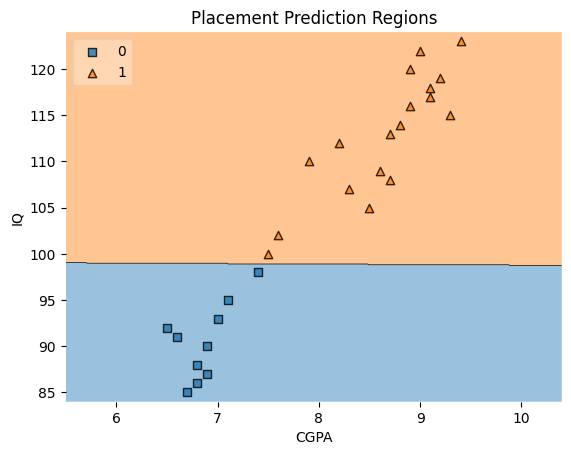

In [72]:
from mlxtend.plotting import plot_decision_regions

# Step 1: Prepare 2D NumPy arrays (CGPA vs IQ)
X_plot = x_train[['CGPA', 'IQ']].values  # Or iloc[:, 1:3] if Serial first
y_plot = y_train.values

# Step 2: Plot (retrain clf on X_plot if needed)
plot_decision_regions(X=X_plot, y=y_plot, clf=clf, legend=2)
plt.xlabel('CGPA')
plt.ylabel('IQ')
plt.title('Placement Prediction Regions')
plt.show()

In [73]:
import pickle  #using pickle to save the model
pickle.dump(clf,open('model.pkl','wb'))